# Greenland Ice Velocity Helheim Glacier tutorial
The PROMICE Ice Velocity product is a time-series of Greenland Ice Sheet velocity mosaics based on ESA Sentinel-1 SAR offset tracking (spatial resolution: 200 m). A new mosaic spanning 2 Sentinel-1A/-1B/-1C cycles is posted every 12 days, with each new mosaic supplied as a NetCDF file. The data product is described in detail in [Solgaard et al. (2021)](https://doi.org/10.5194/essd-13-3491-2021). We aim to make each new mosaic available within 10 days of the last included acquisition.

Here, we will look at how to query and fetch the dataset from our [Thredds server](https://thredds.geus.dk/), which is where we store and operationally update the PROMICE Ice Velocity product. Specifically, we will use the example of Helheim Glacier in Southwest Greenland to look at:
1. Connecting to the PROMICE Ice Velocity aggregated dataset using OpenDAP
2. Querying and fetching data from a given point
3. Querying and fetching data from a given region

So first, let's import all the packages we will be using.

In [2]:
# For dataset loading and handling
import xarray as xr

# For plotting
import matplotlib.pyplot as plt

## 1. Connecting to the PROMICE Ice Velocity aggregated dataset using OpenDAP
The PROMICE Ice Velocity product is available on the [GEUS Thredds server](https://thredds.geus.dk/) as a aggregated dataset. This means that all the data is stored in one file. First let's connect to this dataset using OpenDAP querying. With this, we can load the data structure but not actually downloaded anything. This is one of the strengths of OpenDAP querying - we can inspect the data without actually beginning the heavy operation of downloading.

In [3]:
url = "https://thredds.geus.dk/thredds/dodsC/IVData/IV_ROTR_Agg.nc"
ds = xr.open_dataset(url)

ds

<xarray.Dataset> Size: 873GB
Dimensions:                                  (time: 308, bnds: 2, y: 13500,
                                              x: 7500)
Coordinates:
  * time                                     (time) datetime64[ns] 2kB 2016-0...
  * y                                        (y) float64 108kB -6.5e+05 ... -...
  * x                                        (x) float64 60kB -6.5e+05 ... 8....
Dimensions without coordinates: bnds
Data variables:
    crs                                      |S64 64B ...
    time_bnds                                (time, bnds) datetime64[ns] 5kB ...
    land_ice_surface_easting_velocity        (time, y, x) float32 125GB ...
    land_ice_surface_northing_velocity       (time, y, x) float32 125GB ...
    land_ice_surface_vertical_velocity       (time, y, x) float32 125GB ...
    land_ice_surface_velocity_magnitude      (time, y, x) float32 125GB ...
    land_ice_surface_easting_velocity_std    (time, y, x) float32 125GB ...
    land_ice_surface_northing_velocity_std   (time, y, x) float32 125GB ...
    land_ice_surface_velocity_magnitude_std  (time, y, x) float32 125GB ...
Attributes:
    Conventions:          CF-1.5
    time_coverage_start:  2026-02-04
    time_coverage_end:    2026-02-28
    sensors_used:         Sentinel-1A,Sentinel-1C
    institution:          GEUS
    methods_used:         Offset-tracking
    calibration_method:   None
    title:                Greenland Ice Velocity from 2026-02-04 to 2026-02-28
    summary:              Greenland Ice Velocity from Sentinel-1 offset track...
    product_version:      1.0
    DODS.strlen:          0

Let's inspect the data then. You can see we have three dimensions (listed as coordinates)- a time dimension called `time`, and two spatical dimensions called `x` and `y` which represent latitute and longitude.

We also have a number of variables. Let's look at these a little closer to get some more information about them.

In [3]:
ds.variables

Frozen({'crs': <xarray.Variable ()> Size: 64B
[1 values with dtype=|S64]
Attributes:
    grid_mapping_name:                      polar_stereographic
    standard_parallel:                      70.0
    longitude_of_prime_meridian:            0.0
    straight_vertical_longitude_from_pole:  -45.0
    semi_major_axis:                        6378137.0
    inverse_flattening:                     298.257223563
    latitude_of_projection_origin:          90.0
    false_easting:                          0.0
    false_northing:                         0.0, 'time_bnds': <xarray.Variable (time: 308, bnds: 2)> Size: 5kB
[616 values with dtype=datetime64[ns]]
Attributes:
    _ChunkSizes:  [1 2], 'land_ice_surface_easting_velocity': <xarray.Variable (time: 308, y: 13500, x: 7500)> Size: 125GB
[31185000000 values with dtype=float32]
Attributes:
    units:          m/day
    description:    easting ice velocity
    grid_mapping:   crs
    cell_methods:   time: mean (weighted average (based on error es

Here, we have listed all of the metadata associated with the data variables, including a long name, description and spatial projection. We have directional ice velocity variables (`land_ice_surface_easting_velocity` and `land_ice_surface_northing_velocity`) and the horizontal ice velocity magnitude (`land_ice_surface_velocity_magnitude`), along with vertical ice velocity magnitude (`land_ice_surface_vertical_velocity`), and the errors associated with these velocities (ending with `_std`).

Next, let's look at the spatial coordinates, which will be useful when we come to the next step for extracting data from a specified point, or region.

In [4]:
x_min = ds["x"].min().values
x_max = ds["x"].max().values

y_min = ds["y"].min().values
y_max = ds["y"].max().values

print(x_min)
print(x_max)
print(y_min)
print(y_max)

-650000.0
849800.0
-3349800.0
-650000.0


These coordinates and the range we can query from to download data for a specific point or region. Let's now move on to downloading data for a given point, but firstly close the dataset object we just opened. This is best practise to close the remote connection to the dataset and free up system resources.

In [8]:
ds.close()
del ds

## 2. Querying and fetching data from a given point
We will now define a point location and download data from the nearest grid point. We'll start with a point on Helheim Glacier.

In [10]:
# Define point at Helheim Glacier
x = 302500      # lat metres (EPSG:3413)
y = -2578000    # lon metres (EPSG:3413)

# Open dataset and extract nearest grid point
with xr.open_dataset(url) as ds:
    pt = ds.sel(
        x = x,
        y = y,
        method="nearest"
    )

# Close connection to dataset
ds.close()
del ds

# Show point dataset object
pt

Note:Caching=1


<xarray.Dataset> Size: 16kB
Dimensions:                                  (time: 308, bnds: 2)
Coordinates:
  * time                                     (time) datetime64[ns] 2kB 2016-0...
    y                                        float64 8B -2.578e+06
    x                                        float64 8B 3.026e+05
Dimensions without coordinates: bnds
Data variables:
    crs                                      |S64 64B ...
    time_bnds                                (time, bnds) datetime64[ns] 5kB ...
    land_ice_surface_easting_velocity        (time) float32 1kB ...
    land_ice_surface_northing_velocity       (time) float32 1kB ...
    land_ice_surface_vertical_velocity       (time) float32 1kB ...
    land_ice_surface_velocity_magnitude      (time) float32 1kB ...
    land_ice_surface_easting_velocity_std    (time) float32 1kB ...
    land_ice_surface_northing_velocity_std   (time) float32 1kB ...
    land_ice_surface_velocity_magnitude_std  (time) float32 1kB ...
Attributes:
    Conventions:          CF-1.5
    time_coverage_start:  2026-02-04
    time_coverage_end:    2026-02-28
    sensors_used:         Sentinel-1A,Sentinel-1C
    institution:          GEUS
    methods_used:         Offset-tracking
    calibration_method:   None
    title:                Greenland Ice Velocity from 2026-02-04 to 2026-02-28
    summary:              Greenland Ice Velocity from Sentinel-1 offset track...
    product_version:      1.0
    DODS.strlen:          0

This returns all variables at the nearest grid cell. If we only need one specific variable we can first select the variable and then inspect the data for that variable. Let's select and inspect the horizontal surface velocity magnitude.

In [22]:
# Select velocity magnitude variable
pt_velocities = pt["land_ice_surface_velocity_magnitude"].values

pt_velocities

array([19.418396, 19.373535, 19.179077, 18.890686, 18.578735, 18.37091 ,
       18.111938, 17.95996 , 18.18042 , 18.249878, 18.646912, 18.606201,
       19.002747,       nan, 18.750488, 18.53717 , 18.562866, 18.5578  ,
       18.450684, 19.08142 , 19.31726 , 19.479736, 19.970825, 20.481323,
       21.156311, 21.033997, 20.770569, 20.667847, 20.867065, 20.93335 ,
       21.16211 , 21.131714, 20.693176, 20.564697, 20.70465 , 20.582458,
       20.72699 , 20.763855, 21.014221, 21.668518, 22.022278, 22.294617,
       23.267029, 23.54242 , 23.182251, 22.714233, 22.96643 , 23.84607 ,
       24.866455, 24.366882, 23.923279, 23.316833, 23.73053 , 23.599487,
       23.244812, 22.947144, 22.76361 , 22.335999, 21.895813, 21.539368,
       21.478027, 21.238586, 21.164734, 21.074951, 21.018005, 20.898743,
       20.860779, 20.806458, 20.580261, 20.460022, 20.715454, 20.65094 ,
       20.711914, 20.810913, 20.632568, 20.661987, 20.759033, 21.058716,
       21.219604, 21.531372, 21.811401, 21.464355, 

We can plot these values as a time-series of ice velocity at this point. In addition, we can present the standard deviation values as error bars in our time-series plot.

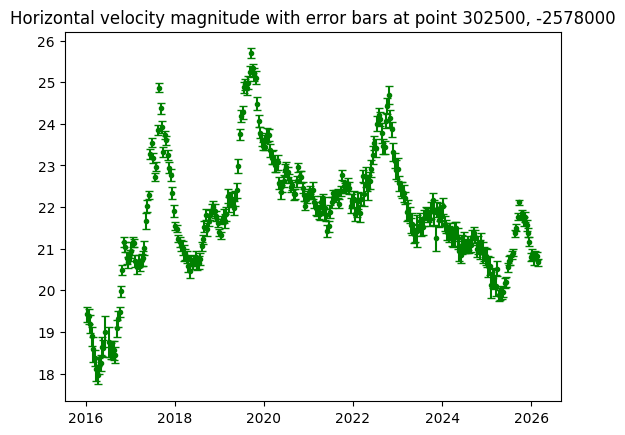

In [36]:
# Prime plotting space
plt.figure()

# Select time and standard deviation variables
pt_time = pt["time"].values
pt_err = pt["land_ice_surface_velocity_magnitude_std"].values

# Plot velocities over time with error bars
plt.errorbar(pt_time,
             pt_velocities,
             yerr=pt_err,
             fmt="o",
             markersize=3,
             capsize=3,
             color="green")
plt.title(f"Horizontal velocity magnitude with error bars at point {x}, {y}")

# Show plot
plt.show()

Another approach to visualising velocities with errors is to use a shaded region between the standard deviation range. This is often clearer than individual error bars in cases like this where we are presenting a long time-series.

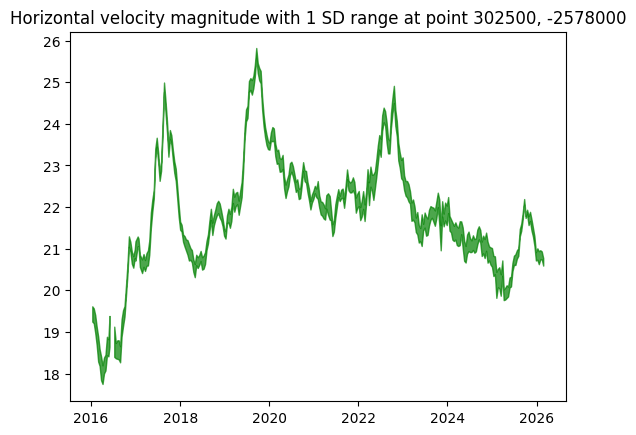

In [37]:
plt.figure()

# Plot velocity with standard deviation as shaded region
plt.fill_between(pt_time,
                 pt_velocities - pt_err,
                 pt_velocities + pt_err,
                 color='green',
                 alpha=0.7)

plt.title(f"Horizontal velocity magnitude with 1 SD range at point {x}, {y}")
plt.show()

## 3. Querying and fetching data from a given region
Let's now define a region and fetch data for a given region. We'll take a region on Helheim Glacier and fetch the dataset.

Note:Caching=1
Note:Caching=1


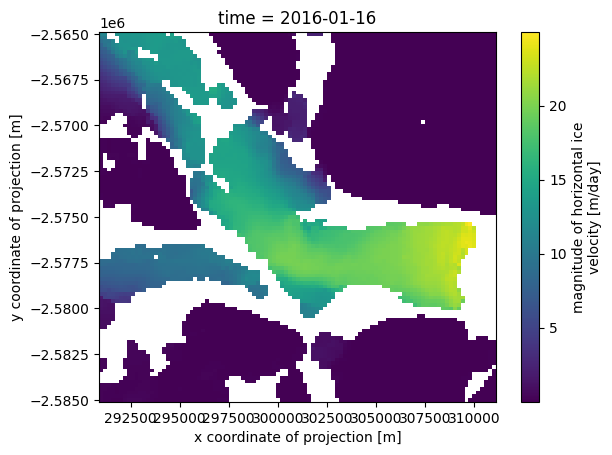

In [43]:
# Define region in lat lon metres (EPSG:3413)
x1=291000
x2=311000
y1=-2565000
y2=-2585000

# Download all variables within this region
with xr.open_dataset(url) as ds:
    region = ds.sel(
        x=slice(x1, x2),
        y=slice(y1, y2)
    )

ds.close()
del ds

# Plot horizontal velocity magnitude for first time step
region_velocities = region["land_ice_surface_velocity_magnitude"]
plt.figure()
region_velocities.isel(time=0).plot()

If we want to produce the average ice velocity over a region then we can calculate the mean of all ice velocity values over the time dimension.

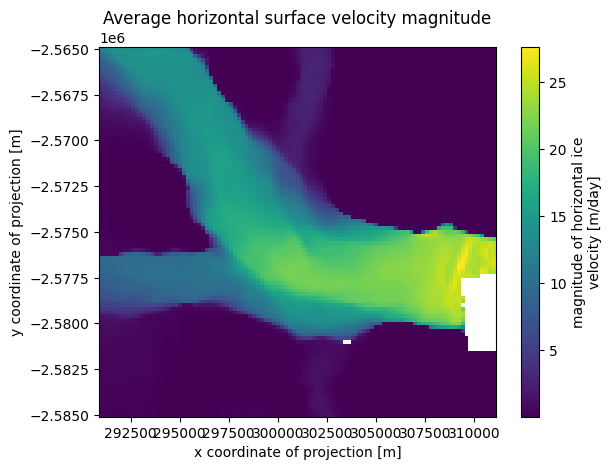

In [45]:
region_average = region_velocities.mean(dim="time")

# Plot average horizontal velocity magnitude at Hagen Brae
plt.figure()
region_average.plot()
plt.title("Average horizontal surface velocity magnitude")
plt.show()

We can also limit our query to a specific time period by providing a time slice. Let's firstly do this for one month in 2025.

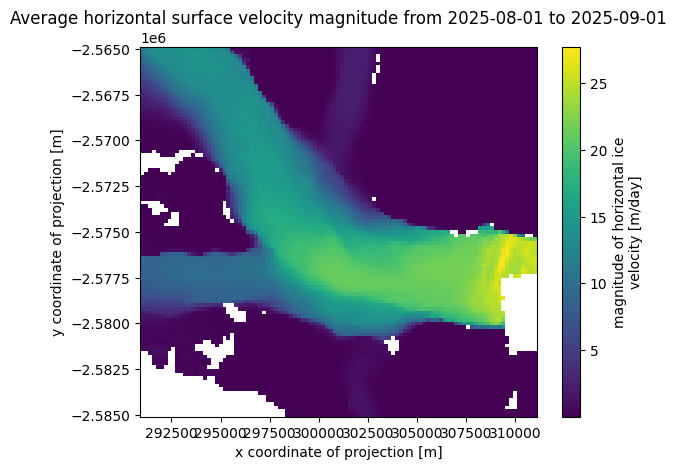

In [46]:
# Define time period
start = "2025-08-01"
end =  "2025-09-01"

# Download all variables within this region
region_velocities_subset = region_velocities.sel(
            time=slice(start, end)
)

# Calculate mean for all values across the defined time period
region_velocities_subset_average = region_velocities_subset.mean(dim="time")

# Plot horizontal velocity magnitude at Hagen Brae for first time step
plt.figure()
region_velocities_subset_average.plot()
plt.title(f"Average horizontal surface velocity magnitude from {start} to {end}")
plt.show()

With this, we could produce a series of plots showing average horizontal surface velocities. This may be useful for examining spatial patterns in ice velocity fields, or producing a series without too many gaps spatially. Let's do this to produce a series of annual summer melt season (May to September) averages.

<Figure size 640x480 with 0 Axes>

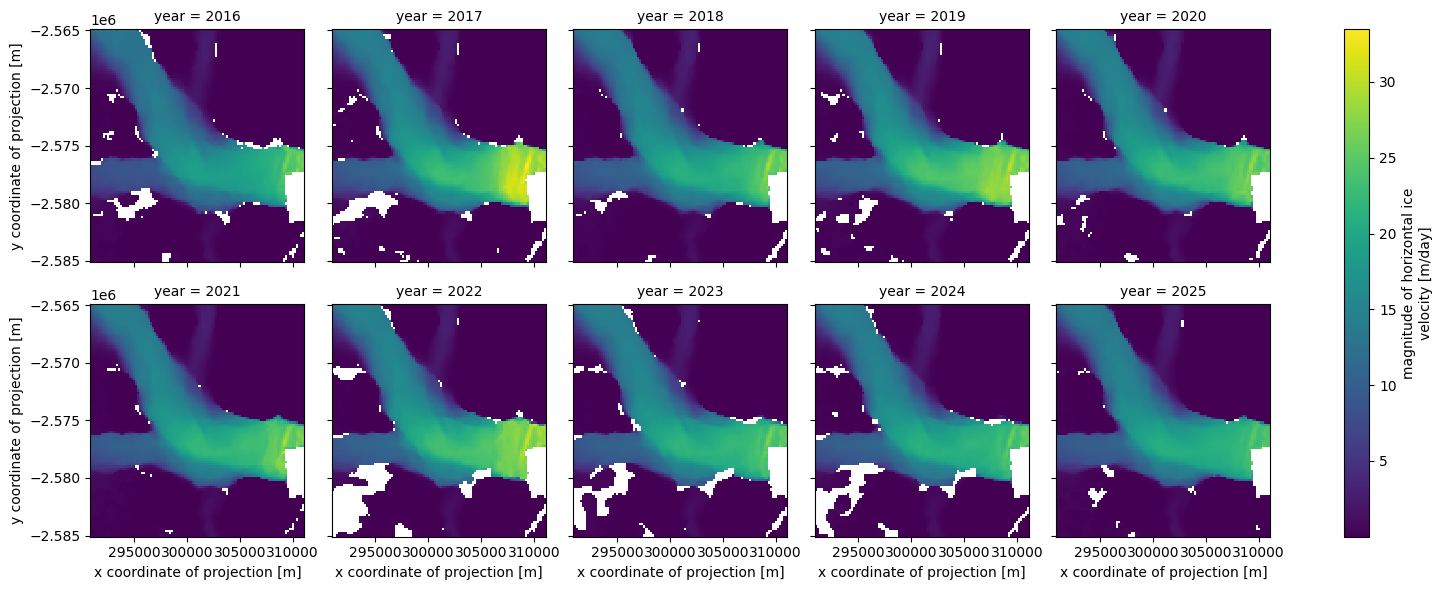

In [54]:
# Select only May (5) to September (9)
summer_velocities = region_velocities.sel(
    time=region_velocities["time"].dt.month.isin([5, 6, 7, 8, 9])
)

# Group by year and compute averages
annual_velocity = summer_velocities.groupby("time.year").mean(dim="time")

# Find max and min values to compute
# consist colour scale
vmin = float(annual_velocity.min())
vmax = float(annual_velocity.max())

# Plot all annual summer melt season velocities
plt.figure()
annual_velocity.plot(
    col="year",
    col_wrap=5,
    vmin=vmin,
    vmax=vmax
)
plt.show()